In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [14]:
dengue = pd.read_csv('datasets\\dengue.csv')
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [15]:
dengue.info()
dengue.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

In [16]:
dengue.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

<h2>The dataset is already clean.</h2>
<h4>Let us proceed with EDA.</h4>

<h2>DENGUE CASES TREND FROM 2016 - 2020</h2>

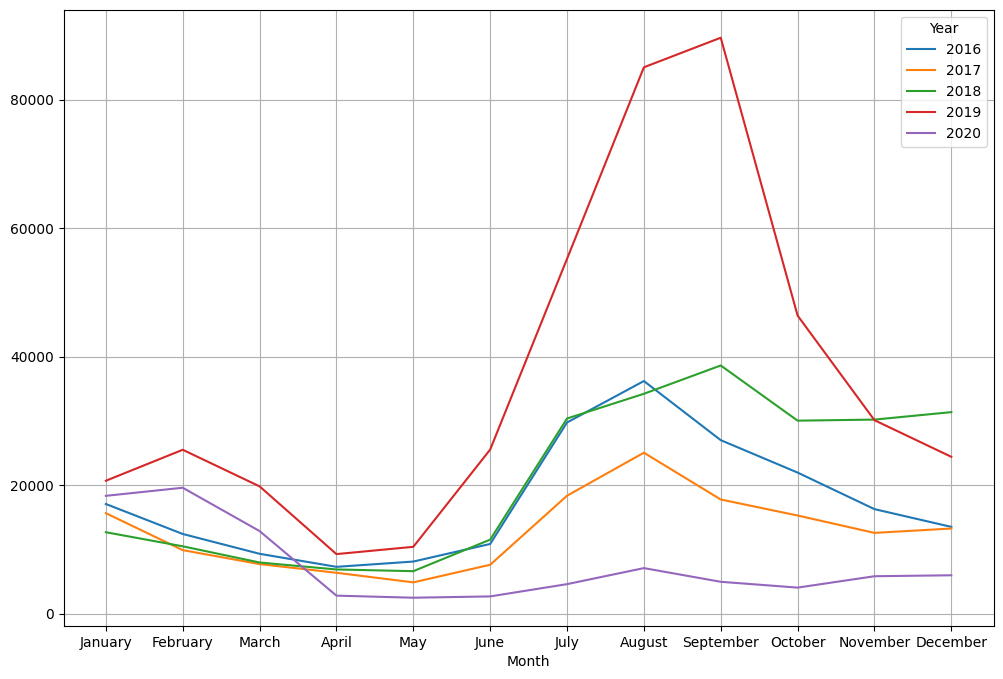

In [17]:
#list
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
dengue['Month'] = pd.Categorical(dengue['Month'], categories=month_order, ordered=True)

monthly_cases = dengue.groupby(["Month", "Year"])["Dengue_Cases"].sum()

monthly_cases.unstack().plot(kind='line')
plt.gcf().set_size_inches(12,8)
plt.grid(True)
plt.xticks(range(0,12), month_order)
plt.show()

<h2> #1. Monthly Trends in Dengue Cases Across Years</h2>

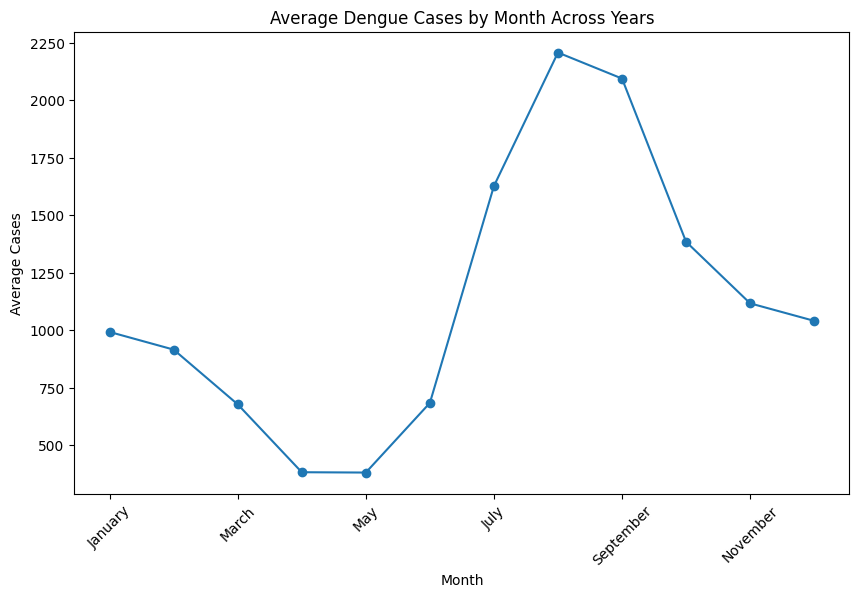

In [38]:
monthly_avg.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Average Dengue Cases by Month Across Years')
plt.ylabel('Average Cases')
plt.xticks(rotation=45)
plt.show()

<hr>
<h2>Insight:</h2>
<p>Monthly Trends in Dengue Cases Across Years
The line plot illustrates the average monthly dengue cases, showing fluctuations across different months.
Notable peaks occur mid-year, particularly in July, indicating a seasonal trend for dengue outbreaks.
In contrast, the months of January to March and September to November exhibit lower case numbers, suggesting a lull in transmission during these periods.</p>
<hr>

<h2>#2. Correlation Between Cases and Deaths </h2>

Correlation coefficient: 0.0383221372041949


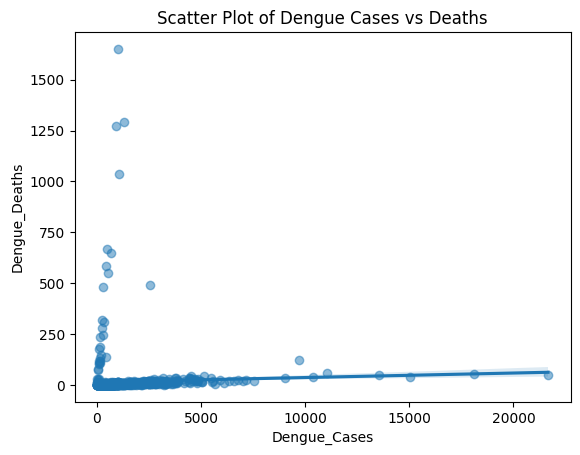

In [19]:
correlation = dengue['Dengue_Cases'].corr(dengue['Dengue_Deaths'])
print(f"Correlation coefficient: {correlation}")

sns.regplot(x='Dengue_Cases', y='Dengue_Deaths', data=dengue, scatter_kws={'alpha':0.5})
plt.title('Scatter Plot of Dengue Cases vs Deaths')
plt.show()

<hr>
<h2>Insight:</h2>
<p>Correlation Between Cases and Deaths
This scatter plot evaluates the relationship between dengue cases and corresponding deaths.
The correlation coefficient of approximately 0.083 suggests a weak positive correlation, indicating that higher case numbers do not necessarily lead to proportionate increases in deaths.
The scatter plot displays a concentration of data points with lower case counts, signifying that most cases result in minimal fatalities.</p>
<hr>

<h2>#3. Comparison of 2019 vs 2020 Cases</h2>

2019: 441902, 2020: 91041, Change: -79.40%


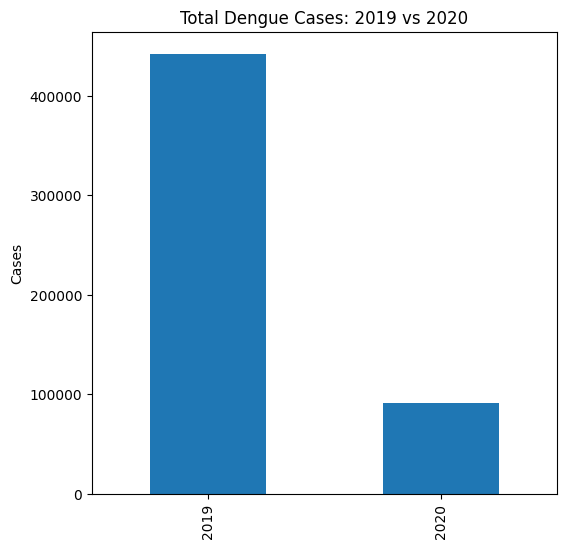

In [20]:
cases_2019 = dengue[dengue['Year'] == 2019]['Dengue_Cases'].sum()
cases_2020 = dengue[dengue['Year'] == 2020]['Dengue_Cases'].sum()
print(f"2019: {cases_2019}, 2020: {cases_2020}, Change: {((cases_2020 - cases_2019) / cases_2019) * 100:.2f}%")

pd.Series({'2019': cases_2019, '2020': cases_2020}).plot(kind='bar', figsize=(6, 6))
plt.title('Total Dengue Cases: 2019 vs 2020')
plt.ylabel('Cases')
plt.show()

<hr>
<h2>Insight:</h2>
<p>Comparison of 2019 vs 2020 Cases
A bar chart compares total dengue cases between 2019 and 2020, highlighting a significant decline in cases.
In 2019, there were 441,982 reported cases, while in 2020, cases dropped to 91,841, reflecting a change of approximately -79.4%.
This stark contrast may suggest effective public health measures or different epidemiological factors that influenced dengue transmission.</p>
<hr>

<h2>#4. Impact of Outbreaks: 2019 Spike Analysis</h2>

2019 Cases: 441902, Avg Other Years: 176380.75, Excess: 265521.25


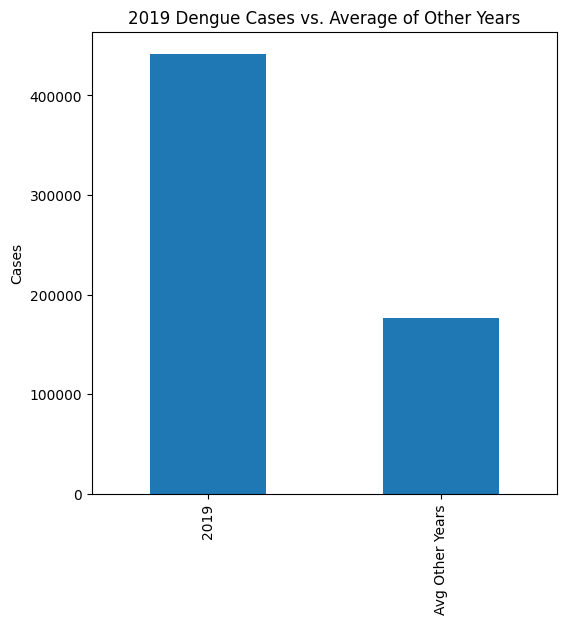

In [21]:
cases_2019 = dengue[dengue['Year'] == 2019]['Dengue_Cases'].sum()
avg_other_years = dengue[dengue['Year'] != 2019].groupby('Year')['Dengue_Cases'].sum().mean()
print(f"2019 Cases: {cases_2019}, Avg Other Years: {avg_other_years}, Excess: {cases_2019 - avg_other_years}")

pd.Series({'2019': cases_2019, 'Avg Other Years': avg_other_years}).plot(kind='bar', figsize=(6, 6))
plt.title('2019 Dengue Cases vs. Average of Other Years')
plt.ylabel('Cases')
plt.show()

<hr>
<h2>Insight:</h2>
<p>Impact of Outbreaks: 2019 Spike Analysis
The bar chart illustrates the number of dengue cases in 2019 in comparison to average cases over other years.
Notably, 2019 exhibited a drastic spike with 441,982 cases, vastly exceeding the average of 176,388.75 cases from other years.
This data underscores the severity and impact of the 2019 outbreak, indicating an unusual increase that warrants further investigation.</p>
<hr>

<h2>#5. Proportion of Deaths by Year</h2>

Year
2016    8127
2017    4563
2018    1226
2019    1733
2020    1195
Name: Dengue_Deaths, dtype: int64


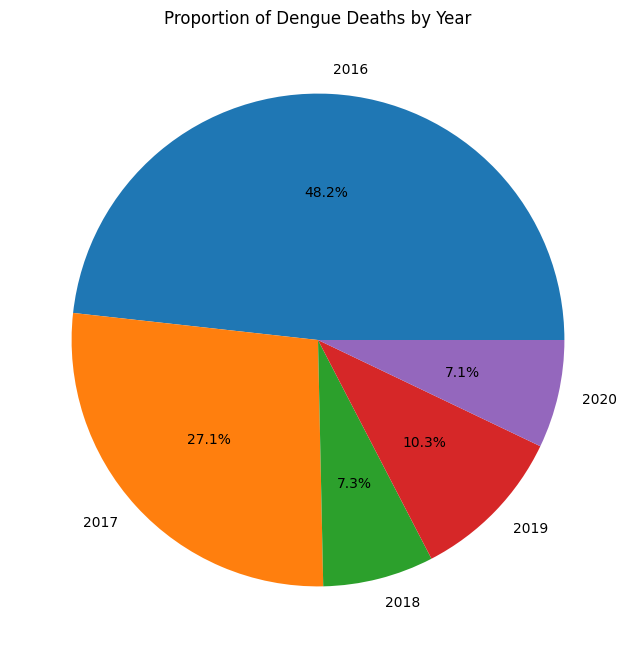

In [22]:
yearly_deaths = dengue.groupby('Year')['Dengue_Deaths'].sum()
print(yearly_deaths)

yearly_deaths.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Proportion of Dengue Deaths by Year')
plt.ylabel('')
plt.show()

<hr>
<h2>Insight:</h2>
<p>Proportion of Deaths by Year
A pie chart displays the proportion of dengue-related deaths across different years from 2016 to 2020.
Notably, 2016 accounts for 48.2% of total deaths, showing it as the most affected year.
The chart allows easy comparison of trends in fatalities, emphasizing years with significant health impacts due to dengue outbreaks</p>
<hr>

<h2>#6. Scatter Plot of Cases vs. Deaths with Region Size</h2>

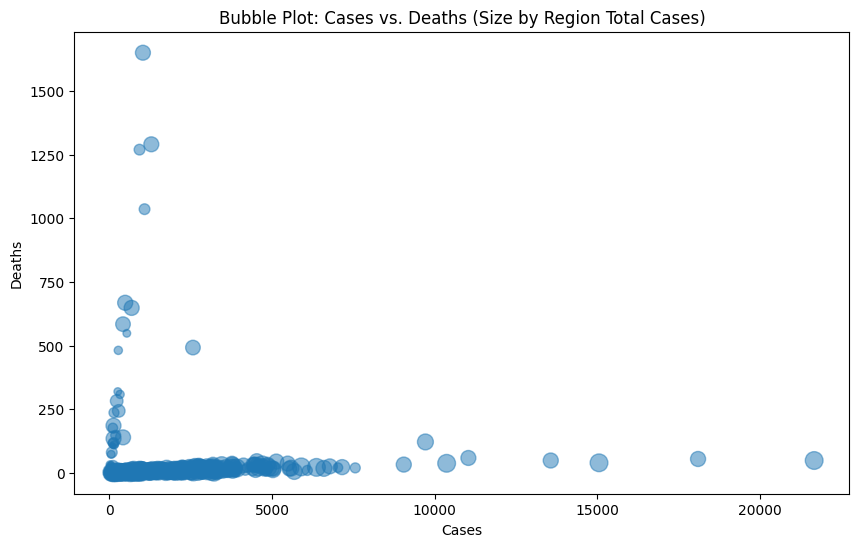

In [23]:
region_size = dengue.groupby('Region')['Dengue_Cases'].sum()
dengue['Region_Size'] = dengue['Region'].map(region_size)

plt.figure(figsize=(10, 6))
plt.scatter(dengue['Dengue_Cases'], dengue['Dengue_Deaths'], s=dengue['Region_Size']/1000, alpha=0.5)
plt.title('Bubble Plot: Cases vs. Deaths (Size by Region Total Cases)')
plt.xlabel('Cases')
plt.ylabel('Deaths')
plt.show()

<hr>
<h2>Insight:</h2>
<p>The plot demonstrates a large number of reported cases with relatively few deaths.
Most points cluster at lower values for both cases and deaths, with a few points higher on the death scale indicating high mortality in specific regions.
It is useful to understand the correlation between cases and deaths in dengue outbreaks.</p>
<hr>

<h2>#7. Which region has the highest total dengue cases?</h2>

Region with highest cases: Region IV-A (163029 cases)


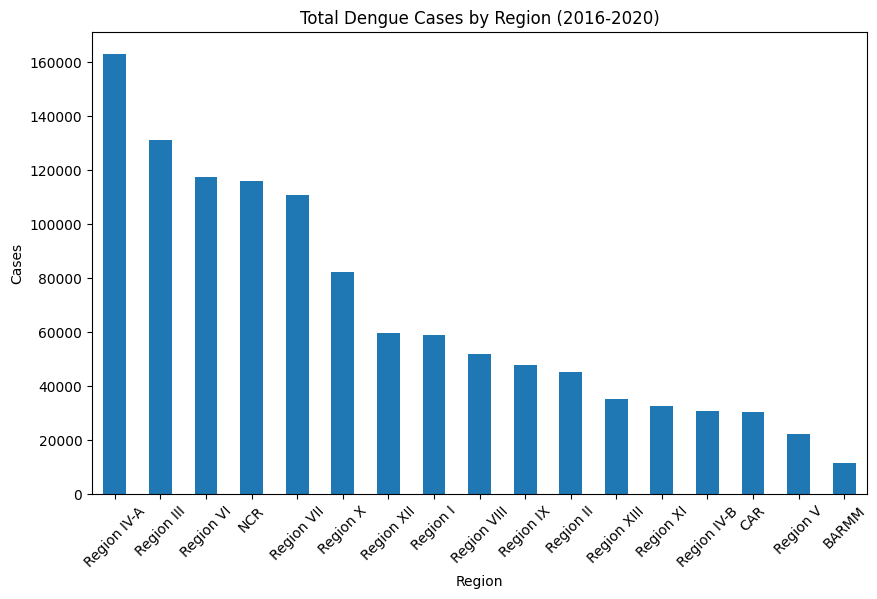

In [29]:
region_cases = dengue.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False)
top_region = region_cases.idxmax()
print(f"Region with highest cases: {top_region} ({region_cases.max()} cases)")

region_cases.plot(kind='bar', figsize=(10, 6))
plt.title('Total Dengue Cases by Region (2016-2020)')
plt.ylabel('Cases')
plt.xticks(rotation=45)
plt.show()

<hr>
<h2>Insight:</h2>
<p>Region IV-A has the highest total cases (163,029 cases).
Other regions like Region III and Region VI have significant cases, but considerably fewer than Region IV-A.
This visualization allows for quick comparisons between regions in terms of case burden.</p>
<hr>

<h2>#8.  What are the average dengue cases by month across all years?</h2>

Month
January       992.094118
February      915.305882
March         677.364706
April         382.447059
May           381.023529
June          683.647059
July         1626.376471
August       2206.517647
September    2093.447059
October      1384.058824
November     1116.470588
December     1040.364706
Name: Dengue_Cases, dtype: float64


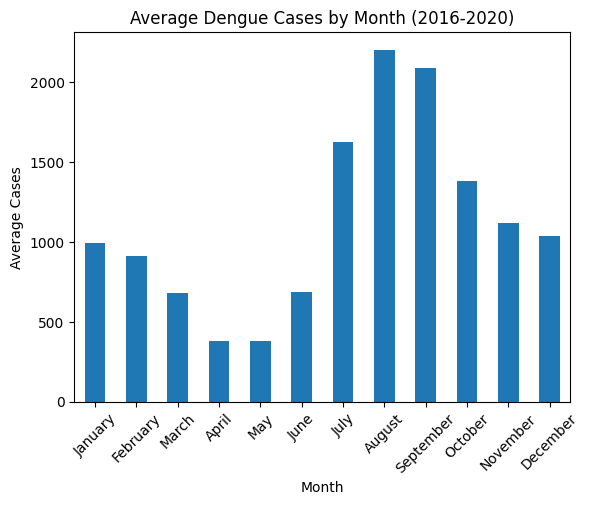

In [28]:
avg_monthly = dengue.groupby('Month')['Dengue_Cases'].mean()
print(avg_monthly)

avg_monthly.plot(kind='bar')
plt.title('Average Dengue Cases by Month (2016-2020)')
plt.ylabel('Average Cases')
plt.xticks(rotation=45)
plt.show()

<hr>
<h2>Insight:</h2>
<p>The peak months for dengue cases appear to be July and August, indicating a possible seasonal trend.
Conversely, January shows the lowest average number of cases.
This helps in planning for preventive measures and deploying resources during peak times.</p>
<hr>

<h2>#9.  Compare cases in rainy season (June-Oct) vs dry season (Nov-May).</h2>

Rainy: 679494, Dry: 467931


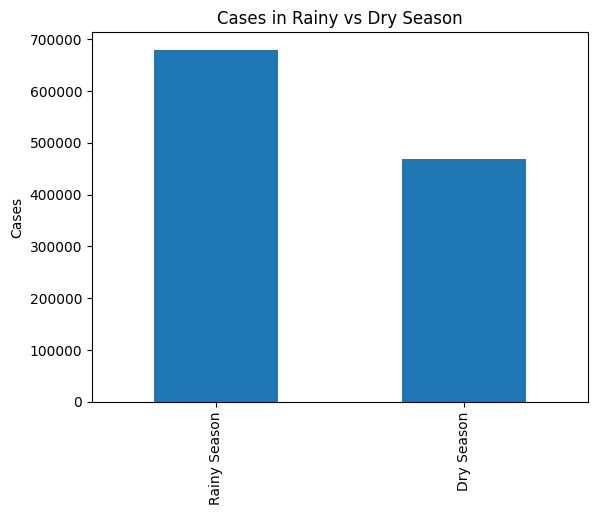

In [31]:
  rainy_months = ['June', 'July', 'August', 'September', 'October']
  dry_months = ['November', 'December', 'January', 'February', 'March', 'April', 'May']
  rainy_cases = dengue[dengue['Month'].isin(rainy_months)]['Dengue_Cases'].sum()
  dry_cases = dengue[dengue['Month'].isin(dry_months)]['Dengue_Cases'].sum()
  print(f"Rainy: {rainy_cases}, Dry: {dry_cases}")

  pd.Series({'Rainy Season': rainy_cases, 'Dry Season': dry_cases}).plot(kind='bar')
  plt.title('Cases in Rainy vs Dry Season')
  plt.ylabel('Cases')
  plt.show()

<hr>
<h2>Insight:</h2>
<p>Dengue cases are significantly higher during the rainy season (679,494 cases) compared to the dry season (467,931 cases).
This analysis highlights the impact of seasonal weather patterns on dengue transmission risks.</p>
<hr>

<h2>#10. Boxplot of dengue cases by region.</h2>

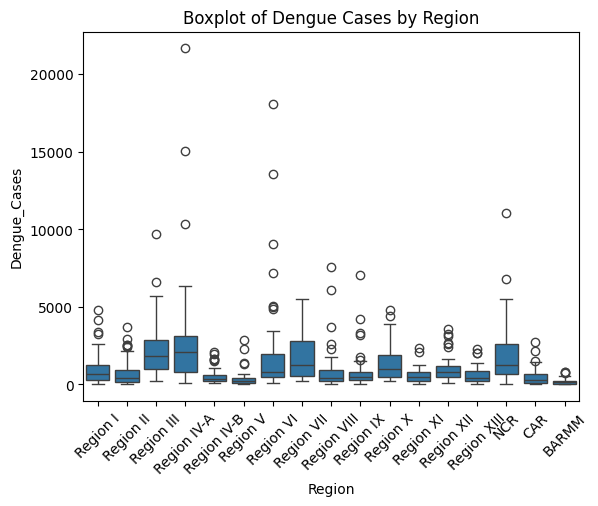

In [35]:
  sns.boxplot(data=dengue, x='Region', y='Dengue_Cases')
  plt.title('Boxplot of Dengue Cases by Region')
  plt.xticks(rotation=45)
  plt.show()


<hr>
<h2>Insight:</h2>
<p>Variation in case load is evident across regions, with some regions showing higher median and interquartile ranges.
Regions like Region IV-A and Region VII appear to have notable wide spreads in case counts, indicating diversity in outbreaks.
Outliers are also present, suggesting that some areas experience severe cases.</p>
<hr>